In [26]:
%pip install recommenders tf_slim catboost -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.2 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.3.5 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [27]:
USE_GPU = False

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"TensorFlow: найдено GPU: {len(gpus)}")
else:
    print("TensorFlow: GPU не найден, используется CPU")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRanker, Pool

from recommenders.models.ncf.ncf_singlenode import NCF
from recommenders.models.ncf.dataset import Dataset as NCFDataset
from recommenders.utils.constants import (
    DEFAULT_USER_COL, DEFAULT_ITEM_COL,
    DEFAULT_RATING_COL, DEFAULT_TIMESTAMP_COL
)

import warnings
warnings.filterwarnings('ignore')

CATBOOST_TASK_TYPE = 'GPU' if USE_GPU else 'CPU'
print(f"CatBoost: task_type='{CATBOOST_TASK_TYPE}'")

np.random.seed(42)

TensorFlow: найдено GPU: 1
CatBoost: task_type='CPU'


In [28]:
df = pd.read_csv('../../data/children_products/clildren_product_cleaned.csv')
print(f"Исходный датасет: {df.shape}")

df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])

MIN_INTERACTIONS = 3
user_counts = df_filtered.groupby('Телефон_new').size()
item_counts = df_filtered.groupby('ID_SKU').size()
active_users = user_counts[user_counts >= MIN_INTERACTIONS].index
active_items = item_counts[item_counts >= MIN_INTERACTIONS].index
df_filtered = df_filtered[
    df_filtered['Телефон_new'].isin(active_users) &
    df_filtered['ID_SKU'].isin(active_items)
]

print(f"Пользователей: {df_filtered['Телефон_new'].nunique():,}")
print(f"Товаров:       {df_filtered['ID_SKU'].nunique():,}")
print(f"Взаимодействий:{len(df_filtered):,}")

Исходный датасет: (610913, 16)
Пользователей: 35,395
Товаров:       22,198
Взаимодействий:314,493


In [ ]:
from recommenders.utils.constants import DEFAULT_TIMESTAMP_COL

interactions = (
    df_filtered
    .groupby(['Телефон_new', 'ID_SKU'])
    .agg(timestamp=('Дата', 'max'))
    .reset_index()
)
interactions[DEFAULT_RATING_COL] = 1.0
interactions.rename(columns={
    'Телефон_new': DEFAULT_USER_COL,
    'ID_SKU':      DEFAULT_ITEM_COL,
    'timestamp':   DEFAULT_TIMESTAMP_COL
}, inplace=True)

interactions = interactions.sort_values(DEFAULT_TIMESTAMP_COL)
split_ts = interactions[DEFAULT_TIMESTAMP_COL].quantile(0.7)
print(f"Дата разделения: {split_ts}")

train_df = interactions[interactions[DEFAULT_TIMESTAMP_COL] <  split_ts].copy()
test_df  = interactions[interactions[DEFAULT_TIMESTAMP_COL] >= split_ts].copy()

train_user_set = set(train_df[DEFAULT_USER_COL].unique())
test_df = test_df[test_df[DEFAULT_USER_COL].isin(train_user_set)]

user2id = {u: i for i, u in enumerate(interactions[DEFAULT_USER_COL].unique())}
item2id = {it: i for i, it in enumerate(interactions[DEFAULT_ITEM_COL].unique())}

def encode(df):
    d = df.copy()
    d[DEFAULT_USER_COL] = d[DEFAULT_USER_COL].map(user2id)
    d[DEFAULT_ITEM_COL] = d[DEFAULT_ITEM_COL].map(item2id)
    return d

train_enc = encode(train_df).sort_values(DEFAULT_USER_COL)
test_enc  = encode(test_df).sort_values(DEFAULT_USER_COL)

df_filtered_with_ids = df_filtered.copy()
df_filtered_with_ids['user_id'] = df_filtered_with_ids['Телефон_new'].map(user2id)
df_filtered_with_ids['item_id'] = df_filtered_with_ids['ID_SKU'].map(item2id)
train_raw = df_filtered_with_ids[df_filtered_with_ids['Дата'] < split_ts]

n_users = len(user2id)
n_items = len(item2id)

print(f"Пользователей: {n_users:,}, Товаров: {n_items:,}")
print(f"Train: {len(train_df):,} пар, {train_df[DEFAULT_USER_COL].nunique():,} users")
print(f"Test:  {len(test_df):,} пар,  {test_df[DEFAULT_USER_COL].nunique():,} users")

Дата разделения: 2017-04-12 17:37:00
Пользователей: 35,395, Товаров: 22,198
Train: 201,147 пар, 28,017 users
Test:  42,415 пар,  7,128 users


In [30]:
import tempfile, os

tmp_dir    = tempfile.mkdtemp()
train_file = os.path.join(tmp_dir, 'train.csv')
test_file  = os.path.join(tmp_dir, 'test.csv')

train_enc[[DEFAULT_USER_COL, DEFAULT_ITEM_COL, DEFAULT_RATING_COL]].to_csv(train_file, index=False)
test_enc[[DEFAULT_USER_COL, DEFAULT_ITEM_COL, DEFAULT_RATING_COL]].to_csv(test_file, index=False)

data = NCFDataset(
    train_file=train_file,
    test_file=test_file,
    seed=42,
    n_neg=4,
    n_neg_test=99,
    col_user=DEFAULT_USER_COL,
    col_item=DEFAULT_ITEM_COL,
    col_rating=DEFAULT_RATING_COL,
)

print(f"NCF Dataset: {data.n_users:,} users, {data.n_items:,} items")

INFO:recommenders.models.ncf.dataset:Indexing /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmpwjxs_3kx/train.csv ...
INFO:recommenders.models.ncf.dataset:Indexing /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmpwjxs_3kx/test.csv ...
INFO:recommenders.models.ncf.dataset:Creating full leave-one-out test file /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmpwjxs_3kx/test_full.csv ...
100%|██████████| 7128/7128 [00:21<00:00, 333.01it/s]
INFO:recommenders.models.ncf.dataset:Indexing /var/folders/2s/l9p15g5j1t3gkzyssvhh423r0000gn/T/tmpwjxs_3kx/test_full.csv ...


NCF Dataset: 28,017 users, 20,699 items


In [31]:
ncf_model = NCF(
    n_users=data.n_users,
    n_items=data.n_items,
    model_type='NeuMF',
    n_factors=64,
    layer_sizes=[256, 128, 64],
    n_epochs=20,
    batch_size=1024,
    learning_rate=1e-3,
    verbose=2,
    seed=42,
)

ncf_model.fit(data)
print("NCF обучен")

2026-04-12 16:42:14.633363: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-12 16:42:14.633379: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 2 [197.22s]: train_loss = 2.292615 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 4 [228.78s]: train_loss = 3.005191 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 6 [189.66s]: train_loss = 3.325629 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 8 [190.77s]: train_loss = 4.058893 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 10 [185.05s]: train_loss = 3.755458 
INFO:recommenders.models.ncf.ncf_singlenode:Epoch 12 [18

NCF обучен


In [ ]:
user_features = train_raw.groupby('user_id').agg(
    user_n_purchases=('Дата', 'count'),
    user_n_unique_items=('item_id', 'nunique'),
    user_avg_price=('Цена', 'mean'),
    user_total_margin=('Маржа', 'sum'),
    user_avg_margin=('Маржа', 'mean'),
).reset_index()

user_geo = train_raw.groupby('user_id')['Гео'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
user_geo.columns = ['user_id', 'user_geo']

user_delivery = train_raw.groupby('user_id')['МетодДоставки_Групп'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
user_delivery.columns = ['user_id', 'user_delivery_method']

user_features = user_features.merge(user_geo, on='user_id').merge(user_delivery, on='user_id')
print(f"User features shape: {user_features.shape}")

User features shape: (28469, 8)


In [ ]:
item_features = train_raw.groupby('item_id').agg(
    item_n_purchases=('Дата', 'count'),
    item_n_unique_buyers=('user_id', 'nunique'),
    item_avg_price=('Цена', 'mean'),
    item_avg_margin=('Маржа', 'mean'),
).reset_index()

item_category = train_raw.groupby('item_id')['Группа2'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 'Неизвестно'
).reset_index()
item_category.columns = ['item_id', 'item_category']

item_features = item_features.merge(item_category, on='item_id')
print(f"Item features shape: {item_features.shape}")

Item features shape: (20745, 6)


In [ ]:
test_user_items = test_enc.groupby(DEFAULT_USER_COL)[DEFAULT_ITEM_COL].apply(list).to_dict()

known_ncf_users = set(ncf_model.user2id.keys())
known_ncf_items = sorted(ncf_model.item2id.keys())

train_user_bought = train_enc.groupby(DEFAULT_USER_COL)[DEFAULT_ITEM_COL].apply(set).to_dict()

eval_users = [u for u in test_user_items if u in known_ncf_users]
print(f"Пользователей для оценки: {len(eval_users):,}")

Пользователей для оценки: 7,128


In [35]:
N_CANDIDATES = 100

rows = []
for i, user_id in enumerate(eval_users):
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/{len(eval_users)}")

    scores = ncf_model.predict(
        [user_id] * len(known_ncf_items),
        known_ncf_items,
        is_list=True
    )

    bought = train_user_bought.get(user_id, set())
    candidate_scores = [
        (item, score) for item, score in zip(known_ncf_items, scores)
        if item not in bought
    ]
    candidate_scores.sort(key=lambda x: x[1], reverse=True)
    candidate_scores = candidate_scores[:N_CANDIDATES]

    relevant = set(test_user_items[user_id])
    for rank, (item_id, score) in enumerate(candidate_scores):
        rows.append({
            'user_id': user_id,
            'item_id': item_id,
            'ncf_score': float(score),
            'ncf_rank': rank + 1,
            'label': int(item_id in relevant)
        })

candidates_df = pd.DataFrame(rows)
print(f"Сгенерировано кандидатов: {len(candidates_df):,}")
print(f"Доля положительных: {candidates_df['label'].mean():.4f}")

  500/7128
  1000/7128
  1500/7128
  2000/7128
  2500/7128
  3000/7128
  3500/7128
  4000/7128
  4500/7128
  5000/7128
  5500/7128
  6000/7128
  6500/7128
  7000/7128
Сгенерировано кандидатов: 712,800
Доля положительных: 0.0060


In [ ]:
dataset = candidates_df.merge(user_features, on='user_id', how='left')
dataset = dataset.merge(item_features, on='item_id', how='left')

num_cols = dataset.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if col not in ['user_id', 'item_id', 'label']:
        dataset[col] = dataset[col].fillna(dataset[col].median())

dataset['user_geo'] = dataset['user_geo'].fillna('Неизвестно')
dataset['user_delivery_method'] = dataset['user_delivery_method'].fillna('Неизвестно')
dataset['item_category'] = dataset['item_category'].fillna('Неизвестно')

print(f"Dataset shape: {dataset.shape}")
print(f"Пропуски: {dataset.isnull().sum().sum()}")

Dataset shape: (712800, 17)
Пропуски: 0


In [37]:
all_cb_users = dataset['user_id'].unique()
np.random.seed(42)
np.random.shuffle(all_cb_users)

split_idx = int(len(all_cb_users) * 0.8)
cb_train_users = set(all_cb_users[:split_idx])
cb_val_users   = set(all_cb_users[split_idx:])

cb_train = dataset[dataset['user_id'].isin(cb_train_users)].sort_values('user_id').copy()
cb_val   = dataset[dataset['user_id'].isin(cb_val_users)].sort_values('user_id').copy()

print(f"CatBoost train: {len(cb_train):,} строк, {len(cb_train_users):,} пользователей")
print(f"CatBoost val:   {len(cb_val):,} строк, {len(cb_val_users):,} пользователей")

CatBoost train: 570,200 строк, 5,702 пользователей
CatBoost val:   142,600 строк, 1,426 пользователей


In [38]:
FEATURE_COLS = [
    'ncf_score', 'ncf_rank',
    'user_n_purchases', 'user_n_unique_items', 'user_avg_price',
    'user_total_margin', 'user_avg_margin',
    'user_geo', 'user_delivery_method',
    'item_n_purchases', 'item_n_unique_buyers',
    'item_avg_price', 'item_avg_margin', 'item_category'
]

CAT_FEATURES = ['user_geo', 'user_delivery_method', 'item_category']

train_pool = Pool(
    data=cb_train[FEATURE_COLS],
    label=cb_train['label'],
    group_id=cb_train['user_id'],
    cat_features=CAT_FEATURES
)
val_pool = Pool(
    data=cb_val[FEATURE_COLS],
    label=cb_val['label'],
    group_id=cb_val['user_id'],
    cat_features=CAT_FEATURES
)

print(f"Features: {len(FEATURE_COLS)} (из них категориальных: {len(CAT_FEATURES)})")

Features: 14 (из них категориальных: 3)


In [39]:
cb_model = CatBoostRanker(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='YetiRank',
    eval_metric='NDCG',
    task_type=CATBOOST_TASK_TYPE,
    random_seed=42,
    verbose=50,
    early_stopping_rounds=30
)

cb_model.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True
)

Groupwise loss function. OneHotMaxSize set to 10
0:	test: 0.7882933	best: 0.7882933 (0)	total: 90.2ms	remaining: 45s
50:	test: 0.8174022	best: 0.8176753 (43)	total: 4.12s	remaining: 36.3s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.8176753403
bestIteration = 43

Shrink model to first 44 iterations.


CatBoostRanker(depth=6, early_stopping_rounds=30, eval_metric='NDCG', iterations=500, learning_rate=0.05, loss_function='YetiRank', random_seed=42, task_type='CPU', verbose=50)

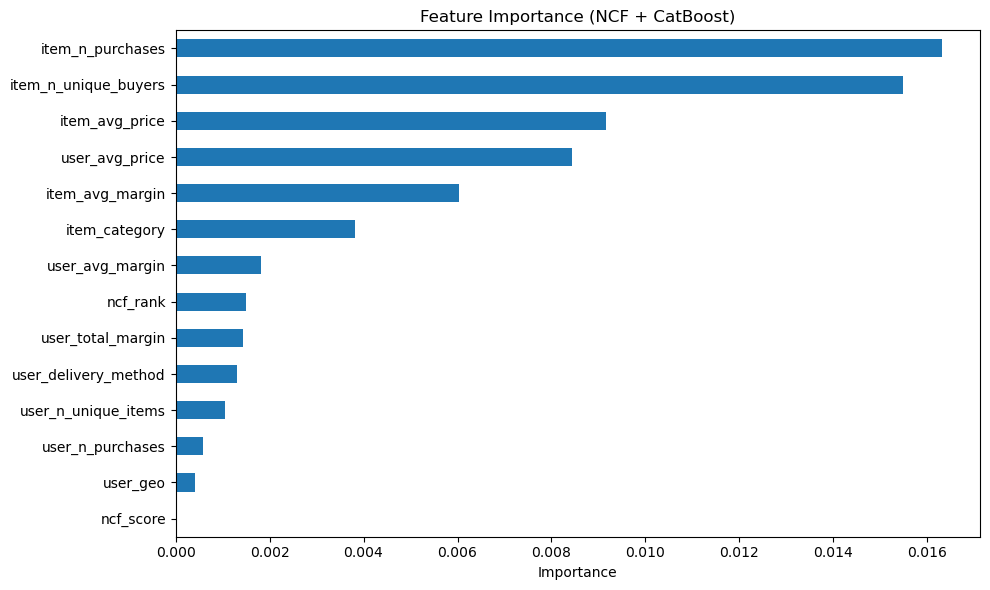

item_n_purchases        0.016305
item_n_unique_buyers    0.015479
item_avg_price          0.009157
user_avg_price          0.008435
item_avg_margin         0.006032
item_category           0.003826
user_avg_margin         0.001808
ncf_rank                0.001504
user_total_margin       0.001428
user_delivery_method    0.001303
user_n_unique_items     0.001058
user_n_purchases        0.000581
user_geo                0.000421
ncf_score               0.000000


In [ ]:
feat_imp = pd.Series(
    cb_model.get_feature_importance(data=train_pool),
    index=FEATURE_COLS
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.title('Feature Importance (NCF + CatBoost)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_imp.to_string())

In [41]:
def precision_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    return len(rec_k & set(relevant)) / len(rec_k) if rec_k else 0.0

def recall_at_k(recommended, relevant, k):
    rec_k = set(recommended[:k])
    return len(rec_k & set(relevant)) / len(set(relevant)) if relevant else 0.0

def map_at_k(recommended, relevant, k):
    relevant = set(relevant)
    if not relevant:
        return 0.0
    score, hits = 0.0, 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k)

def ndcg_at_k(recommended, relevant, k):
    relevant = set(relevant)
    if not relevant:
        return 0.0
    dcg  = sum(1.0 / np.log2(i + 2) for i, item in enumerate(recommended[:k]) if item in relevant)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0

In [42]:
def evaluate_hybrid(dataset_df, model, feature_cols, test_user_items, k_values=[5, 10, 20]):
    dataset_df = dataset_df.copy()
    dataset_df['cb_score'] = model.predict(dataset_df[feature_cols])

    results = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}

    for user_id, group in dataset_df.groupby('user_id'):
        if user_id not in test_user_items:
            continue
        ranked = group.sort_values('cb_score', ascending=False)['item_id'].tolist()
        relevant = test_user_items[user_id]
        for k in k_values:
            results[k]['precision'].append(precision_at_k(ranked, relevant, k))
            results[k]['recall'].append(recall_at_k(ranked, relevant, k))
            results[k]['map'].append(map_at_k(ranked, relevant, k))
            results[k]['ndcg'].append(ndcg_at_k(ranked, relevant, k))

    return {k: {m: np.mean(v) for m, v in results[k].items()} for k in k_values}


def evaluate_ncf_only(ncf_model, known_items, train_user_bought, test_user_items, k_values=[5, 10, 20]):
    known_users = set(ncf_model.user2id.keys())
    eval_users = [u for u in test_user_items if u in known_users]

    results = {k: {'precision': [], 'recall': [], 'map': [], 'ndcg': []} for k in k_values}

    for i, user_id in enumerate(eval_users):
        if (i + 1) % 1000 == 0:
            print(f"  {i+1}/{len(eval_users)}")
        scores = ncf_model.predict(
            [user_id] * len(known_items),
            known_items,
            is_list=True
        )
        bought = train_user_bought.get(user_id, set())
        scored = [(item, s) for item, s in zip(known_items, scores) if item not in bought]
        scored.sort(key=lambda x: x[1], reverse=True)
        rec = [item for item, _ in scored]

        relevant = test_user_items[user_id]
        for k in k_values:
            results[k]['precision'].append(precision_at_k(rec, relevant, k))
            results[k]['recall'].append(recall_at_k(rec, relevant, k))
            results[k]['map'].append(map_at_k(rec, relevant, k))
            results[k]['ndcg'].append(ndcg_at_k(rec, relevant, k))

    return {k: {m: np.mean(v) for m, v in results[k].items()} for k in k_values}

In [43]:
k_values = [5, 10, 20]

print("Оцениваем NCF (baseline)...")
ncf_results = evaluate_ncf_only(
    ncf_model, known_ncf_items, train_user_bought, test_user_items, k_values
)

print("Оцениваем NCF + CatBoost...")
hybrid_results = evaluate_hybrid(dataset, cb_model, FEATURE_COLS, test_user_items, k_values)

Оцениваем NCF (baseline)...
  1000/7128
  2000/7128
  3000/7128
  4000/7128
  5000/7128
  6000/7128
  7000/7128
Оцениваем NCF + CatBoost...


In [44]:
print(f"{'Метрика':<20} {'NCF':>10} {'NCF+CatBoost':>14} {'Прирост':>10}")
print("-" * 56)

for k in k_values:
    for metric in ['precision', 'recall', 'map', 'ndcg']:
        base_val   = ncf_results[k][metric]
        hybrid_val = hybrid_results[k][metric]
        delta = (hybrid_val - base_val) / (base_val + 1e-10) * 100
        sign = '+' if delta >= 0 else ''
        print(f"{metric.upper()+'@'+str(k):<20} {base_val:>10.4f} {hybrid_val:>14.4f} {sign+f'{delta:.1f}%':>10}")
    print()

Метрика                     NCF   NCF+CatBoost    Прирост
--------------------------------------------------------
PRECISION@5              0.0042         0.0300    +622.3%
RECALL@5                 0.0018         0.0422   +2186.9%
MAP@5                    0.0017         0.0312   +1784.9%
NDCG@5                   0.0036         0.0453   +1171.1%

PRECISION@10             0.0061         0.0245    +303.5%
RECALL@10                0.0067         0.0612    +812.5%
MAP@10                   0.0019         0.0307   +1534.7%
NDCG@10                  0.0059         0.0506    +760.7%

PRECISION@20             0.0079         0.0185    +133.2%
RECALL@20                0.0211         0.0757    +259.0%
MAP@20                   0.0032         0.0310    +876.1%
NDCG@20                  0.0115         0.0552    +381.6%



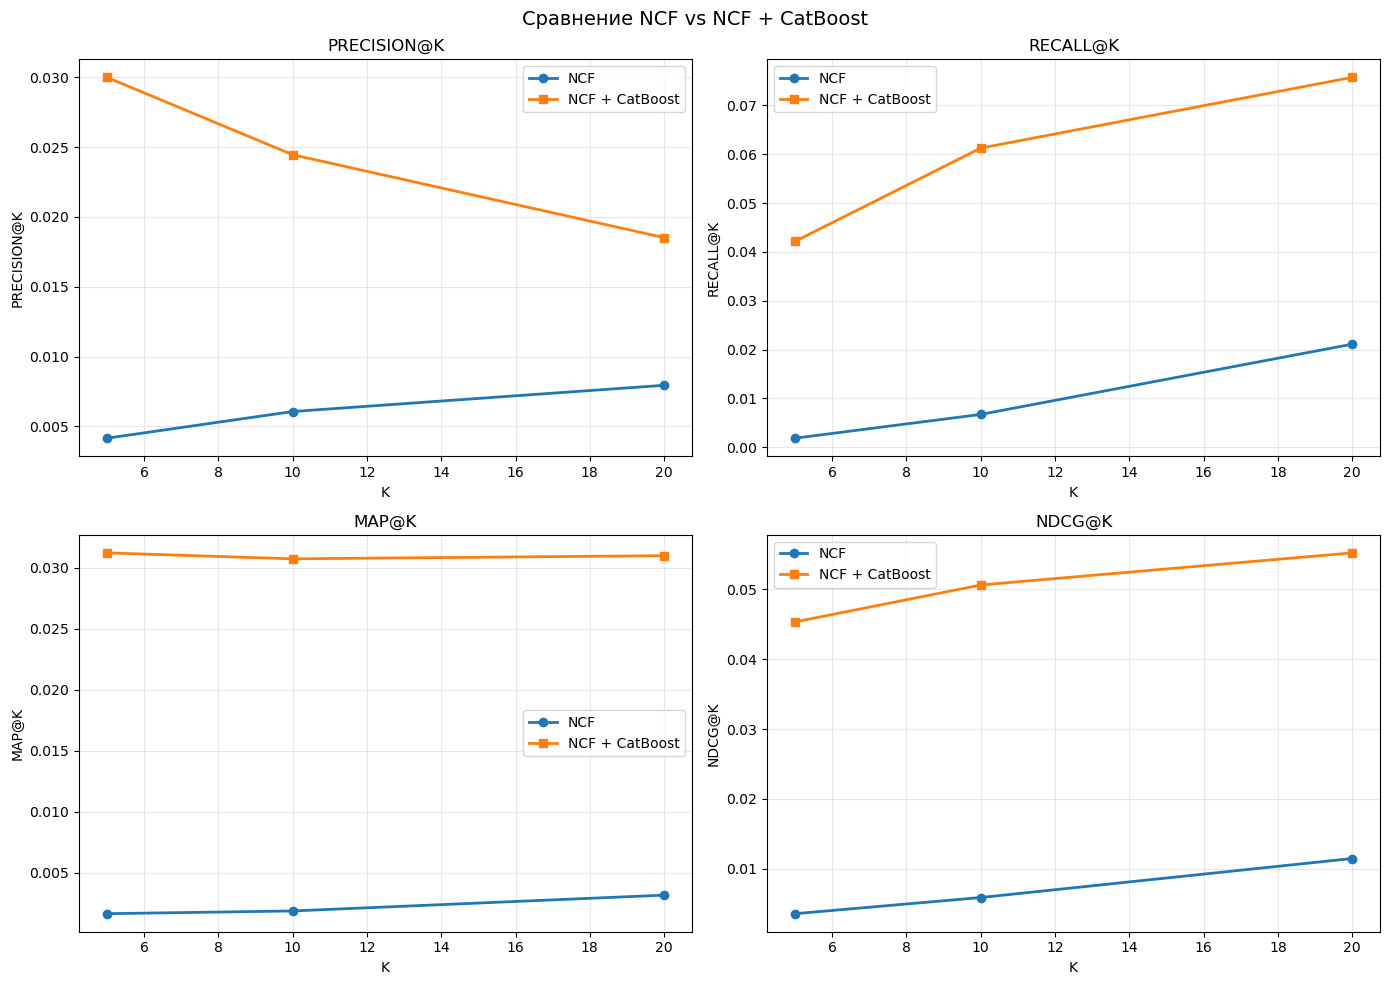

In [45]:
metrics_list = ['precision', 'recall', 'map', 'ndcg']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric in zip(axes.flat, metrics_list):
    base_vals   = [ncf_results[k][metric] for k in k_values]
    hybrid_vals = [hybrid_results[k][metric] for k in k_values]
    ax.plot(k_values, base_vals,   marker='o', label='NCF', linewidth=2)
    ax.plot(k_values, hybrid_vals, marker='s', label='NCF + CatBoost', linewidth=2)
    ax.set_xlabel('K')
    ax.set_ylabel(f'{metric.upper()}@K')
    ax.set_title(f'{metric.upper()}@K')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение NCF vs NCF + CatBoost', fontsize=14)
plt.tight_layout()
plt.show()